# Mean-only blend weights

Test fixed **5%,10%,20%,30%,40%,50% corrected-polling shares**, plus0% Bayesian. No weight is learned from the cycle being evaluated. The same inputs and full Bayesian covariance are used at every weight.

`mean = (1-w) × Bayesian_mean + w × corrected_polling_mean`

The operation shifts every joint simulation by a constant per state. Standard deviations, margin correlations and interval widths remain unchanged; seat-count uncertainty can change after thresholding. These two forecast horizons do not establish a continuous seasonal schedule.

In [2]:
from pathlib import Path
import sys, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = next(p for p in [Path.cwd(), Path.cwd().parent] if (p/'election_lab.py').exists())
sys.path.insert(0, str(ROOT))
import election_lab as lab
pd.set_option('display.max_rows', 40)

RUN = lab.run_logged(lab.weight_experiment)
pred = pd.read_parquet(RUN/'predictions.parquet')
summary = pd.read_parquet(RUN/'summary.parquet')
ORDER = ['Bayesian'] + [f'Corrected {w}%' for w in [5,10,20,30,40,50]]

Run log: cache/logs/weight_experiment_20260921T044206.452744Z.txt


## 1. Compare history at both horizons

2016–2024: five cycles,140 contests per horizon. Lower MAE/Brier is better;70% coverage should be near70%. Small differences across this repeatedly studied sample do not establish a unique optimal weight.

In [3]:
recent = summary[summary.first_cycle.eq(2016)]
for horizon in ['matched_live','oct31']:
    print(horizon)
    display(recent[recent.scenario.eq(horizon)].set_index('model').loc[ORDER,['n','correct','absolute_error_pp','brier','coverage70','width70_pp']].round(4))

matched_live


,n,correct,absolute_error_pp,brier,coverage70,width70_pp
model,,,,,,
Bayesian,140,128,6.3067,0.0555,0.7821,19.8764
Corrected 5%,140,129,6.2957,0.0555,0.7964,19.8764
Corrected 10%,140,129,6.2860,0.0556,0.8036,19.8764
Corrected 20%,140,129,6.2772,0.0560,0.8097,19.8764
Corrected 30%,140,129,6.3364,0.0566,0.8030,19.8764
Corrected 40%,140,129,6.4375,0.0574,0.7961,19.8764
Corrected 50%,140,129,6.5649,0.0585,0.7964,19.8764


oct31


,n,correct,absolute_error_pp,brier,coverage70,width70_pp
model,,,,,,
Bayesian,140,132,5.2060,0.0504,0.7317,15.7997
Corrected 5%,140,132,5.1578,0.0499,0.7471,15.7997
Corrected 10%,140,133,5.1141,0.0493,0.7471,15.7997
Corrected 20%,140,133,5.0349,0.0483,0.7548,15.7997
Corrected 30%,140,133,4.9831,0.0474,0.7550,15.7997
Corrected 40%,140,133,4.9564,0.0467,0.7486,15.7997
Corrected 50%,140,133,4.9394,0.0460,0.7486,15.7997


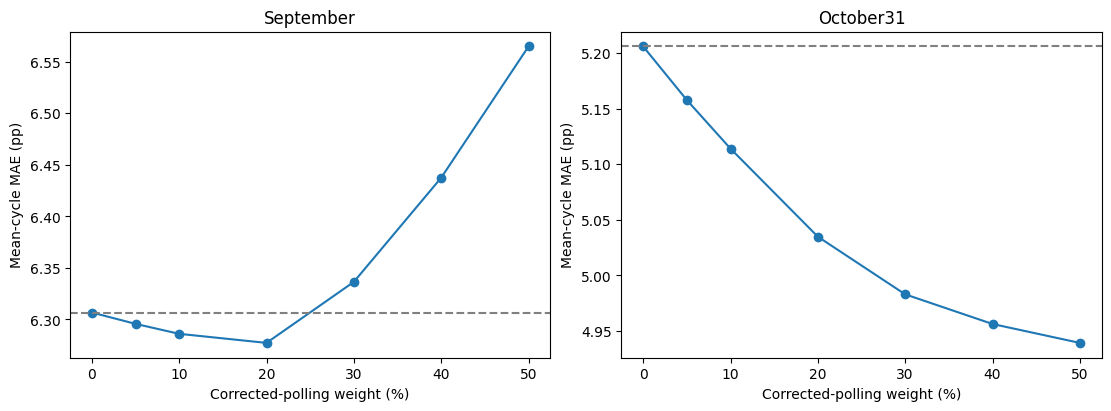

In [4]:
fig, axes = plt.subplots(1,2,figsize=(11,4),constrained_layout=True)
for ax,horizon in zip(axes,['matched_live','oct31']):
    g=recent[recent.scenario.eq(horizon)].set_index('model').loc[ORDER]
    ax.plot([0,5,10,20,30,40,50],g.absolute_error_pp,marker='o')
    ax.axhline(g.absolute_error_pp.iloc[0],color='gray',ls='--')
    ax.set(title='September' if horizon=='matched_live' else 'October31',xlabel='Corrected-polling weight (%)',ylabel='Mean-cycle MAE (pp)')
plt.show()

## 2. Check individual cycles

A pooled improvement can hide reversals. Recent late-horizon gains are concentrated in2020/2024. All older included cycles remain below.

In [5]:
cycle = pd.read_parquet(RUN/'cycle_scores.parquet')
for horizon in ['matched_live','oct31']:
    print(horizon)
    display(cycle[cycle.scenario.eq(horizon)].pivot(index='cycle',columns='model',values='absolute_error_pp')[ORDER].round(3))

matched_live


model,Bayesian,Corrected 5%,Corrected 10%,Corrected 20%,Corrected 30%,Corrected 40%,Corrected 50%
cycle,,,,,,,
2012,7.486,7.492,7.499,7.512,7.525,7.538,7.551
2014,10.222,10.289,10.360,10.502,10.731,10.990,11.249
2016,7.846,7.949,8.052,8.299,8.623,8.976,9.329
2018,3.761,3.744,3.726,3.698,3.727,3.761,3.803
2020,7.847,7.765,7.683,7.522,7.504,7.506,7.535
2022,7.391,7.446,7.500,7.610,7.759,7.925,8.117
2024,4.688,4.575,4.469,4.257,4.070,4.020,4.040


oct31


model,Bayesian,Corrected 5%,Corrected 10%,Corrected 20%,Corrected 30%,Corrected 40%,Corrected 50%
cycle,,,,,,,
2012,5.400,5.439,5.477,5.555,5.632,5.710,5.787
2014,5.545,5.502,5.459,5.469,5.500,5.542,5.584
2016,6.629,6.650,6.671,6.713,6.754,6.870,6.986
2018,3.442,3.456,3.470,3.498,3.530,3.570,3.619
2020,6.345,6.244,6.143,5.975,5.882,5.788,5.695
2022,5.327,5.291,5.278,5.257,5.272,5.330,5.404
2024,4.287,4.148,4.009,3.731,3.477,3.224,2.993


## 3. Current seats and unchanged covariance

Frozen September17 data. We do not choose a weight to obtain a preferred2026 political outcome.

In [6]:
now=pd.read_parquet(RUN/'seats.parquet').query('cycle == 2026').set_index('model').loc[ORDER].copy()
now['D control %']=100*now.p_D_control
display(now[['point_D','point_R','expected_D','D control %','D_lo70','D_hi70']].round(3))
widths=pred[pred.model.isin(ORDER)].groupby(['scenario','cycle','target_id']).width70_pp.agg(lambda x:np.ptp(x))
assert widths.max()<1e-10
print('All state interval widths unchanged.')

,point_D,point_R,expected_D,D control %,D_lo70,D_hi70
model,,,,,,
Bayesian,51,49,50.426,48.270,49,52
Corrected 5%,51,49,50.364,46.723,49,52
Corrected 10%,51,49,50.300,44.980,49,52
Corrected 20%,51,49,50.166,41.833,49,52
Corrected 30%,51,49,50.024,38.773,48,52
Corrected 40%,51,49,49.874,35.637,48,52
Corrected 50%,51,49,49.717,32.617,48,51


All state interval widths unchanged.


## Conclusion

September has a shallow MAE minimum around10–20%, with no probability/chamber improvement. October benefits through50%, with diminishing margin gains after30–40%. This suggests a timing-dependent hypothesis, not a validated schedule or a single best weight.

## Saved reports

[Read the published report](../outputs/reports/experiments/blend_weights.md) · [All outputs and dated reports](../outputs/README.md)
